# 05 — Model Training

Trains **GBR** (HistGradientBoostingRegressor) and **CatBoost** on all combinations of:
- 4 turbidity datasets (base, log1p, trimmed 1–99, Yeo-Johnson)
- 5 patch sizes (16 → 256 px)

**Total runs:** 4 × 5 × 2 = **40 training experiments**

Train/test split: **stratified by turbidity** at the date level (mean turbidity per date binned into 5 quantile groups; ~20 % of dates sampled from each bin → test set covers the full turbidity range).

Hyperparameter optimisation: **Optuna** (TPE, 30 trials) with **GroupKFold** CV (k=5, groups by date) inside each objective.

**Outputs** in `results/`:
- `model_metrics.csv` — all 40 combinations with train/OOF/CV/test metrics
- `test_predictions.csv` — per-sample test set predictions
- `oof_predictions.csv` — out-of-fold train predictions
- `best_model_info.json` — best combination pointer
- `models/` — fitted model pickles

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
RANDOM_STATE = 6912

## 1. Configuration

In [14]:
BASE_DIR = Path('..')
FE_DIR   = BASE_DIR / 'data' / 'processed' / 'feature_engineering'
PROC_DIR = BASE_DIR / 'data' / 'processed'
RES_DIR  = BASE_DIR / 'results'
MOD_DIR  = RES_DIR / 'models'
for d in [RES_DIR, MOD_DIR]:
    d.mkdir(exist_ok=True)

DATASET_CONFIG = {
    'base':       {'file': 'dataset_base.csv',         'clip_at_zero': True},
    'log1p':      {'file': 'dataset_log1p.csv',        'clip_at_zero': True},
    'trimmed':    {'file': 'dataset_trimmed_1_99.csv', 'clip_at_zero': True},
    'yeojohnson': {'file': 'dataset_yeojohnson.csv',   'clip_at_zero': False},
}

PATCH_CONFIG = [
    {'px': 16,  'diameter_m': 48},
    {'px': 32,  'diameter_m': 96},
    {'px': 64,  'diameter_m': 192},
    {'px': 128, 'diameter_m': 384},
    {'px': 256, 'diameter_m': 768},
]

META_COLS        = ['ctd', 'date', 'turbidity']
TEST_FRAC        = 0.20
N_CV_SPLITS      = 5
EARLY_STOP       = 50
N_MAX_ITERS      = 800
N_OPTUNA_TRIALS  = 30

print(f'Datasets   : {list(DATASET_CONFIG.keys())}')
print(f'Patch sizes: {[c["px"] for c in PATCH_CONFIG]} px')
print(f'Models     : GBR, CatBoost')

Datasets   : ['base', 'log1p', 'trimmed', 'yeojohnson']
Patch sizes: [16, 32, 64, 128, 256] px
Models     : GBR, CatBoost


## 2. Data loading and utility functions

In [15]:
def load_training_data(patch_px: int, ds_name: str):
    """
    Merge feature file (from 04_feature_engineering) with a turbidity dataset.

    Returns (df, feat_cols) where df has cols ctd + date + turbidity + features.
    """
    feat_path = FE_DIR / f'fe_{patch_px}px.parquet'
    if not feat_path.exists():
        raise FileNotFoundError(f'{feat_path} not found — run 04_feature_engineering first.')

    df_feat = pd.read_parquet(feat_path)
    df_feat['date'] = pd.to_datetime(df_feat['date']).dt.date
    df_feat['ctd']  = df_feat['ctd'].astype(str)

    cfg     = DATASET_CONFIG[ds_name]
    df_turb = pd.read_csv(PROC_DIR / cfg['file'])
    df_turb['date'] = pd.to_datetime(df_turb['date']).dt.date
    df_turb['ctd']  = df_turb['ctd'].astype(str)

    df = df_feat.merge(df_turb[['ctd', 'date', 'turbidity']], on=['ctd', 'date'], how='inner')
    df = df.dropna(subset=['turbidity']).reset_index(drop=True)

    feat_cols = [c for c in df.columns if c not in META_COLS]
    return df, feat_cols


def stratified_turbidity_split(df, test_frac=TEST_FRAC, n_bins=5, random_state=RANDOM_STATE):
    """
    Split at the date level, stratified by mean turbidity per date.

    Dates are ranked by their mean turbidity and divided into n_bins quantile
    groups.  ~test_frac of the dates in each bin are assigned to the test set,
    so the test set covers the full turbidity range rather than being limited
    to the most recent (and possibly atypical) acquisition period.

    Splitting at the date level prevents leakage: all CTD stations observed
    on the same satellite acquisition date always belong to the same split.
    """
    date_turb = (df.groupby('date')['turbidity'].mean()
                   .reset_index(name='mean_turb')
                   .sort_values('mean_turb')
                   .reset_index(drop=True))

    n_bins_actual = min(n_bins, len(date_turb))
    date_turb['bin'] = pd.qcut(date_turb['mean_turb'], q=n_bins_actual,
                                labels=False, duplicates='drop')

    rng = np.random.default_rng(random_state)
    test_dates = []
    for bin_id in sorted(date_turb['bin'].unique()):
        bin_dates = date_turb.loc[date_turb['bin'] == bin_id, 'date'].tolist()
        n_test    = max(1, round(len(bin_dates) * test_frac))
        chosen    = rng.choice(bin_dates, size=min(n_test, len(bin_dates)),
                               replace=False).tolist()
        test_dates.extend(chosen)

    tr_df = df[~df['date'].isin(test_dates)].reset_index(drop=True)
    te_df = df[ df['date'].isin(test_dates)].reset_index(drop=True)
    return tr_df, te_df


def compute_metrics(y_true, y_pred):
    y_pred = np.asarray(y_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    return dict(
        mae       = round(mean_absolute_error(y_true, y_pred), 4),
        rmse      = round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        r2        = round(r2_score(y_true, y_pred), 4),
        pearson_r = round(float(pearsonr(y_true, y_pred)[0]), 4),
        bias      = round(float(np.mean(y_pred - y_true)), 4),
    )


print('Utility functions loaded.')

Utility functions loaded.


## 3. Optuna objectives

Bayesian (TPE) search with GroupKFold inside the objective — no temporal leakage during tuning.

In [16]:
def _gbr_objective(trial, X_tr, y_tr, groups):
    params = dict(
        learning_rate     = trial.suggest_float('learning_rate',     0.01, 0.30, log=True),
        max_leaf_nodes    = trial.suggest_int(  'max_leaf_nodes',    15, 127),
        min_samples_leaf  = trial.suggest_int(  'min_samples_leaf',  1, 40),
        l2_regularization = trial.suggest_float('l2_regularization', 1e-6, 10.0, log=True),
        max_features      = trial.suggest_float('max_features',      0.5, 1.0),
        loss              = trial.suggest_categorical('loss', ['squared_error', 'absolute_error']),
    )
    kf     = GroupKFold(n_splits=N_CV_SPLITS)
    scores = []
    for tr_idx, val_idx in kf.split(X_tr, y_tr, groups):
        m = HistGradientBoostingRegressor(
            max_iter=N_MAX_ITERS,
            n_iter_no_change=EARLY_STOP,
            validation_fraction=0.12,
            random_state=RANDOM_STATE,
            **params
        )
        m.fit(X_tr[tr_idx], y_tr[tr_idx])
        scores.append(mean_absolute_error(y_tr[val_idx], m.predict(X_tr[val_idx])))
    return float(np.mean(scores))


def _cat_objective(trial, X_tr, y_tr, groups):
    params = dict(
        depth               = trial.suggest_int(  'depth',               4, 10),
        learning_rate       = trial.suggest_float('learning_rate',       0.01, 0.30, log=True),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg',         1.0, 20.0),
        min_data_in_leaf    = trial.suggest_int(  'min_data_in_leaf',    1, 20),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 2.0),
    )
    kf     = GroupKFold(n_splits=N_CV_SPLITS)
    scores = []
    for tr_idx, val_idx in kf.split(X_tr, y_tr, groups):
        m = CatBoostRegressor(
            iterations=N_MAX_ITERS,
            loss_function='MAE',
            eval_metric='MAE',
            bootstrap_type='Bayesian',
            random_seed=RANDOM_STATE,
            thread_count=-1,
            verbose=False,
            **params
        )
        m.fit(X_tr[tr_idx], y_tr[tr_idx],
              eval_set=(X_tr[val_idx], y_tr[val_idx]),
              early_stopping_rounds=EARLY_STOP,
              verbose=False)
        scores.append(mean_absolute_error(y_tr[val_idx], m.predict(X_tr[val_idx])))
    return float(np.mean(scores))


def run_optuna(model_type, X_tr, y_tr, groups, n_trials=N_OPTUNA_TRIALS):
    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    if model_type == 'GBR':
        obj = lambda t: _gbr_objective(t, X_tr, y_tr, groups)
    else:
        obj = lambda t: _cat_objective(t, X_tr, y_tr, groups)
    study.optimize(obj, n_trials=n_trials, show_progress_bar=False)
    print(f'    Optuna({n_trials} trials): CV_MAE={study.best_value:.4f}')
    return dict(study.best_params)


print('Optuna objectives loaded.')

Optuna objectives loaded.


## 4. CV with early stopping and final training

In [17]:
def cv_early_stopping(model_type, X_tr, y_tr, groups, best_params):
    """
    GroupKFold CV with early stopping.
    Returns (oof_preds, fold_metrics, best_iters_per_fold).
    """
    kf      = GroupKFold(n_splits=N_CV_SPLITS)
    oof     = np.full(len(y_tr), np.nan)
    fold_met = []
    best_its = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_tr, y_tr, groups)):
        Xtr, Xval = X_tr[tr_idx], X_tr[val_idx]
        ytr, yval = y_tr[tr_idx], y_tr[val_idx]

        if model_type == 'GBR':
            p = {k: v for k, v in best_params.items()}
            m = HistGradientBoostingRegressor(
                max_iter=N_MAX_ITERS,
                n_iter_no_change=EARLY_STOP,
                validation_fraction=0.12,
                random_state=RANDOM_STATE,
                **p
            )
            m.fit(Xtr, ytr)
            best_its.append(m.n_iter_)
            pred = m.predict(Xval)

        else:  # CatBoost
            p = {k: v for k, v in best_params.items() if k != 'loss'}
            m = CatBoostRegressor(
                iterations=N_MAX_ITERS,
                loss_function='MAE',
                eval_metric='MAE',
                bootstrap_type='Bayesian',
                random_seed=RANDOM_STATE,
                thread_count=-1,
                verbose=False,
                **p
            )
            m.fit(Xtr, ytr,
                  eval_set=(Xval, yval),
                  early_stopping_rounds=EARLY_STOP,
                  verbose=False)
            best_its.append(m.get_best_iteration())
            pred = m.predict(Xval)

        oof[val_idx] = pred
        fold_met.append(compute_metrics(yval, pred))

    return oof, fold_met, best_its


def train_final(model_type, X_tr, y_tr, best_its, best_params):
    """Train final model on full training set. n_iters = round(mean CV best_iters) + 1."""
    n_iters = max(int(round(np.mean(best_its))) + 1, 10)

    if model_type == 'GBR':
        p = {k: v for k, v in best_params.items()}
        m = HistGradientBoostingRegressor(
            max_iter=n_iters,
            random_state=RANDOM_STATE,
            **p
        )
        m.fit(X_tr, y_tr)
    else:
        p = {k: v for k, v in best_params.items() if k != 'loss'}
        m = CatBoostRegressor(
            iterations=n_iters,
            loss_function='MAE',
            eval_metric='MAE',
            bootstrap_type='Bayesian',
            random_seed=RANDOM_STATE,
            thread_count=-1,
            verbose=False,
            **p
        )
        m.fit(X_tr, y_tr, verbose=False)

    return m, n_iters


print('CV and training functions loaded.')

CV and training functions loaded.


## 5. Training loop: 4 datasets × 5 patches × 2 models

In [18]:
models_to_train = ['GBR', 'CatBoost']

all_results  = []
oof_records  = []
test_records = []

total_runs = len(DATASET_CONFIG) * len(PATCH_CONFIG) * len(models_to_train)
run_idx    = 0

print(f'Starting {total_runs} training runs...\n')

for ds_name, ds_cfg in DATASET_CONFIG.items():
    for pc in PATCH_CONFIG:
        px = pc['px']

        try:
            df, feat_cols = load_training_data(px, ds_name)
        except FileNotFoundError as e:
            print(f'  SKIP [{ds_name}/{px}px] {e}')
            continue

        tr_df, te_df = stratified_turbidity_split(df)

        X_tr = tr_df[feat_cols].values.astype(np.float64)
        X_te = te_df[feat_cols].values.astype(np.float64)
        y_tr = tr_df['turbidity'].values
        y_te = te_df['turbidity'].values

        # GroupKFold groups by date — no temporal leakage across folds
        groups = pd.Categorical(tr_df['date']).codes

        for mtype in models_to_train:
            run_idx += 1
            print(f'[{run_idx}/{total_runs}] dataset={ds_name:10s}  patch={px:3d}px  model={mtype}')

            print(f'  Searching hyperparameters ({N_OPTUNA_TRIALS} trials)...', flush=True)
            best_params = run_optuna(mtype, X_tr, y_tr, groups)

            print(f'  CV (k={N_CV_SPLITS})...', flush=True)
            oof, fold_met, best_its = cv_early_stopping(mtype, X_tr, y_tr, groups, best_params)

            cv_mae     = float(np.mean([m['mae']  for m in fold_met]))
            cv_mae_std = float(np.std( [m['mae']  for m in fold_met]))
            cv_rmse    = float(np.mean([m['rmse'] for m in fold_met]))
            cv_r2      = float(np.mean([m['r2']   for m in fold_met]))

            final_model, n_iters = train_final(mtype, X_tr, y_tr, best_its, best_params)

            clip = ds_cfg['clip_at_zero']

            tr_pred  = final_model.predict(X_tr)
            te_pred  = final_model.predict(X_te)
            if clip:
                tr_pred = np.maximum(tr_pred, 0.0)
                te_pred = np.maximum(te_pred, 0.0)
                oof     = np.where(np.isnan(oof), np.nan, np.maximum(oof, 0.0))

            tr_met  = compute_metrics(y_tr, tr_pred)
            te_met  = compute_metrics(y_te, te_pred)
            oof_met = compute_metrics(y_tr, oof)

            print(f'  n_iters={n_iters:4d} | '
                  f'Train MAE={tr_met["mae"]:.3f} R²={tr_met["r2"]:.3f} | '
                  f'OOF MAE={oof_met["mae"]:.3f} | '
                  f'CV {cv_mae:.3f}±{cv_mae_std:.3f} | '
                  f'Test MAE={te_met["mae"]:.3f} R²={te_met["r2"]:.3f}')

            model_key = f'{ds_name}__{px}px__{mtype}'
            pickle.dump(final_model, open(MOD_DIR / f'{model_key}.pkl', 'wb'))
            pickle.dump(feat_cols,   open(MOD_DIR / f'{model_key}__feat_cols.pkl', 'wb'))

            all_results.append({
                'dataset': ds_name, 'patch_px': px, 'diameter_m': pc['diameter_m'],
                'model': mtype,
                'n_train': len(tr_df), 'n_test': len(te_df),
                'n_features': len(feat_cols), 'n_iters': n_iters,
                **{f'train_{k}': v for k, v in tr_met.items()},
                **{f'test_{k}':  v for k, v in te_met.items()},
                **{f'oof_{k}':   v for k, v in oof_met.items()},
                'cv_mae':          round(cv_mae, 4),
                'cv_mae_std':      round(cv_mae_std, 4),
                'cv_rmse':         round(cv_rmse, 4),
                'cv_r2':           round(cv_r2, 4),
                'best_iter_mean':  round(float(np.mean(best_its)), 1),
                'best_iter_std':   round(float(np.std(best_its)), 1),
                'best_params':     json.dumps(best_params),
            })

            for row_df, pred_val in zip(te_df.itertuples(index=False), te_pred):
                test_records.append({
                    'ctd': row_df.ctd, 'date': str(row_df.date),
                    'turbidity': row_df.turbidity, 'pred': round(float(pred_val), 6),
                    'dataset': ds_name, 'patch_px': px, 'model': mtype,
                })

            for row_df, oof_val in zip(tr_df.itertuples(index=False), oof):
                oof_records.append({
                    'ctd': row_df.ctd, 'date': str(row_df.date),
                    'turbidity': row_df.turbidity, 'pred': round(float(oof_val), 6),
                    'dataset': ds_name, 'patch_px': px, 'model': mtype,
                })

print(f'\nTraining complete — {run_idx} runs finished.')

Starting 40 training runs...

[1/40] dataset=base        patch= 16px  model=GBR
  Searching hyperparameters (30 trials)...
    Optuna(30 trials): CV_MAE=0.7387
  CV (k=5)...
  n_iters= 801 | Train MAE=0.474 R²=0.195 | OOF MAE=0.739 | CV 0.739±0.343 | Test MAE=0.681 R²=-0.229
[2/40] dataset=base        patch= 16px  model=CatBoost
  Searching hyperparameters (30 trials)...
    Optuna(30 trials): CV_MAE=0.6943
  CV (k=5)...
  n_iters=  10 | Train MAE=0.461 R²=0.256 | OOF MAE=0.694 | CV 0.694±0.329 | Test MAE=0.617 R²=-0.102
[3/40] dataset=base        patch= 32px  model=GBR
  Searching hyperparameters (30 trials)...
    Optuna(30 trials): CV_MAE=0.7481
  CV (k=5)...
  n_iters= 801 | Train MAE=0.486 R²=0.189 | OOF MAE=0.748 | CV 0.748±0.343 | Test MAE=0.674 R²=-0.275
[4/40] dataset=base        patch= 32px  model=CatBoost
  Searching hyperparameters (30 trials)...
    Optuna(30 trials): CV_MAE=0.7018
  CV (k=5)...
  n_iters=  16 | Train MAE=0.665 R²=-0.026 | OOF MAE=0.702 | CV 0.702±0.331 | 

## 6. Save metrics and predictions to CSV

In [19]:
metrics_df = pd.DataFrame(all_results)
test_df    = pd.DataFrame(test_records)
oof_df     = pd.DataFrame(oof_records)

metrics_df.to_csv(RES_DIR / 'model_metrics.csv',      index=False)
test_df.to_csv(   RES_DIR / 'test_predictions.csv',   index=False)
oof_df.to_csv(    RES_DIR / 'oof_predictions.csv',    index=False)

best_row = metrics_df.loc[metrics_df['test_mae'].idxmin()]
best_cfg = {
    'best_dataset':   best_row['dataset'],
    'best_patch_px':  int(best_row['patch_px']),
    'best_model':     best_row['model'],
    'diameter_m':     int(best_row['diameter_m']),
    'test_mae':       float(best_row['test_mae']),
    'test_r2':        float(best_row['test_r2']),
    'model_file':     f'{best_row["dataset"]}__{best_row["patch_px"]}px__{best_row["model"]}.pkl',
    'feat_cols_file': f'{best_row["dataset"]}__{best_row["patch_px"]}px__{best_row["model"]}__feat_cols.pkl',
}
with open(RES_DIR / 'best_model_info.json', 'w') as f:
    json.dump(best_cfg, f, indent=2)
with open(RES_DIR / 'dataset_config.json', 'w') as f:
    json.dump(DATASET_CONFIG, f, indent=2)

print(f'Saved model_metrics.csv     ({len(metrics_df)} rows)')
print(f'Saved test_predictions.csv  ({len(test_df)} rows)')
print(f'Saved oof_predictions.csv   ({len(oof_df)} rows)')
print(f'\nBest combination:')
print(f'  dataset={best_cfg["best_dataset"]}  patch={best_cfg["best_patch_px"]}px  '
      f'model={best_cfg["best_model"]}')
print(f'  Test MAE={best_cfg["test_mae"]:.4f}  R²={best_cfg["test_r2"]:.4f}')

Saved model_metrics.csv     (40 rows)
Saved test_predictions.csv  (1838 rows)
Saved oof_predictions.csv   (11222 rows)

Best combination:
  dataset=log1p  patch=64px  model=CatBoost
  Test MAE=0.2532  R²=-0.0916


## 7. Results table

In [20]:
cols_show = ['dataset', 'patch_px', 'model',
             'train_mae', 'train_r2',
             'oof_mae',
             'cv_mae', 'cv_mae_std',
             'test_mae', 'test_rmse', 'test_r2',
             'n_iters']

display(
    metrics_df[cols_show]
    .sort_values('test_mae')
    .reset_index(drop=True)
    .rename(columns={
        'patch_px':    'patch',
        'train_mae':   'Train MAE', 'train_r2':  'Train R²',
        'oof_mae':     'OOF MAE',
        'cv_mae':      'CV MAE',    'cv_mae_std': 'CV ±',
        'test_mae':    'Test MAE',  'test_rmse':  'Test RMSE', 'test_r2': 'Test R²',
    })
)

,dataset,patch,model,Train MAE,Train R²,OOF MAE,CV MAE,CV ±,Test MAE,Test RMSE,Test R²,n_iters
0,log1p,64,CatBoost,0.2234,0.2773,0.2834,0.2841,0.0507,0.2532,0.3646,-0.0916,30
1,log1p,32,CatBoost,0.2373,0.1939,0.2849,0.2856,0.0509,0.2580,0.3694,-0.1204,50
2,log1p,16,CatBoost,0.2159,0.3454,0.2865,0.2872,0.0529,0.2589,0.3681,-0.1122,10
3,log1p,64,GBR,0.1397,0.5492,0.3179,0.3185,0.0543,0.2676,0.3681,-0.1127,801
4,log1p,128,CatBoost,0.2166,0.2490,0.2809,0.2810,0.0759,0.2771,0.3494,-0.2663,16
5,log1p,32,GBR,0.0861,0.7282,0.3137,0.3144,0.0566,0.2869,0.3883,-0.2378,801
6,log1p,256,GBR,0.1788,0.3961,0.2906,0.2912,0.1096,0.2883,0.3491,-0.2619,801
7,log1p,16,GBR,0.0965,0.7058,0.3145,0.3152,0.0584,0.2898,0.4036,-0.3372,801
8,log1p,128,GBR,0.1188,0.6198,0.3119,0.3122,0.0859,0.2974,0.3629,-0.3663,801
9,log1p,256,CatBoost,0.1342,0.6370,0.2674,0.2686,0.1122,0.3092,0.3818,-0.5093,48


## 8. Visualisation

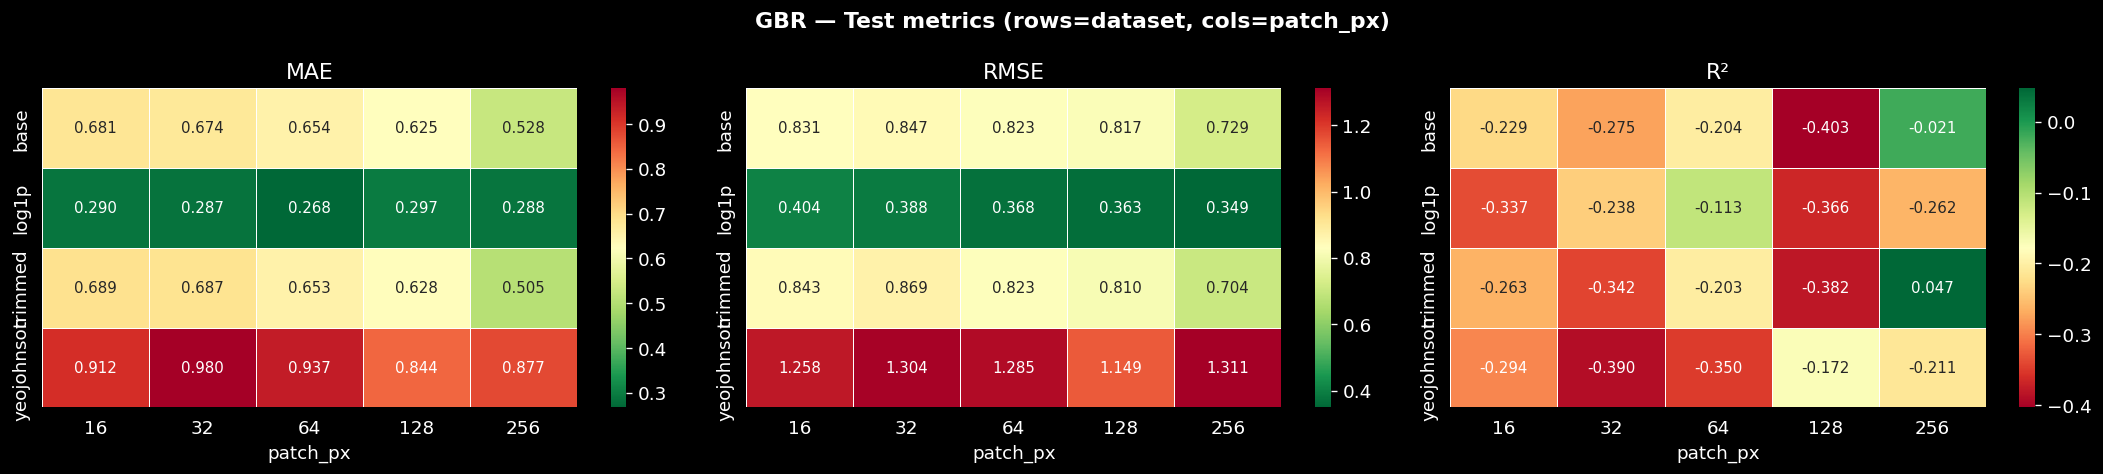

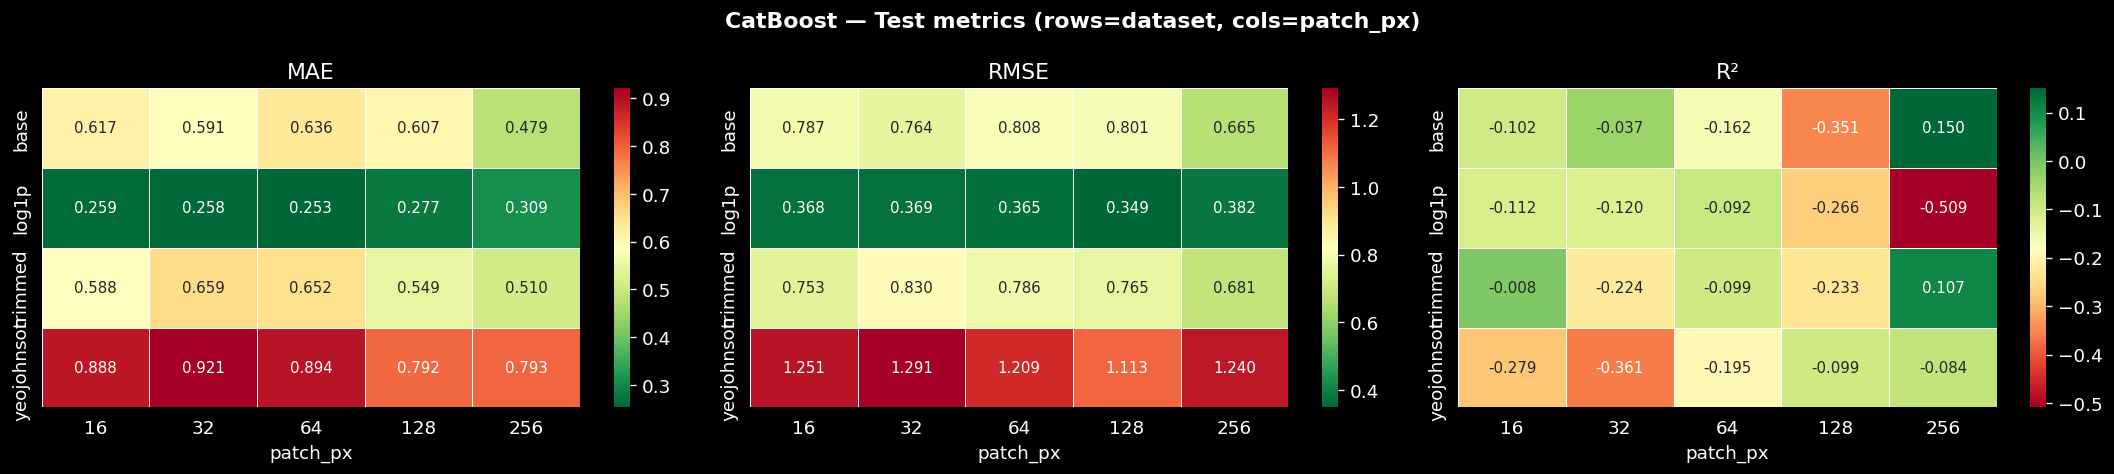

In [21]:
ds_order    = list(DATASET_CONFIG.keys())
px_order    = [c['px'] for c in PATCH_CONFIG]
model_order = ['GBR', 'CatBoost']

for mtype in model_order:
    sub = metrics_df[metrics_df['model'] == mtype]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f'{mtype} — Test metrics (rows=dataset, cols=patch_px)', fontweight='bold')

    for ax, (metric, label, cmap) in zip(axes, [
        ('test_mae',  'MAE',  'RdYlGn_r'),
        ('test_rmse', 'RMSE', 'RdYlGn_r'),
        ('test_r2',   'R²',   'RdYlGn'),
    ]):
        pivot = sub.pivot(index='dataset', columns='patch_px', values=metric)
        pivot = pivot.reindex(
            index=[d for d in ds_order if d in pivot.index],
            columns=[p for p in px_order if p in pivot.columns]
        )
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap,
                    ax=ax, linewidths=0.5, annot_kws={'size': 9})
        ax.set_title(label)
        ax.set_xlabel('patch_px')
        ax.set_ylabel('')

    plt.tight_layout()
    plt.savefig(RES_DIR / f'heatmap_{mtype}.png', bbox_inches='tight')
    plt.show()

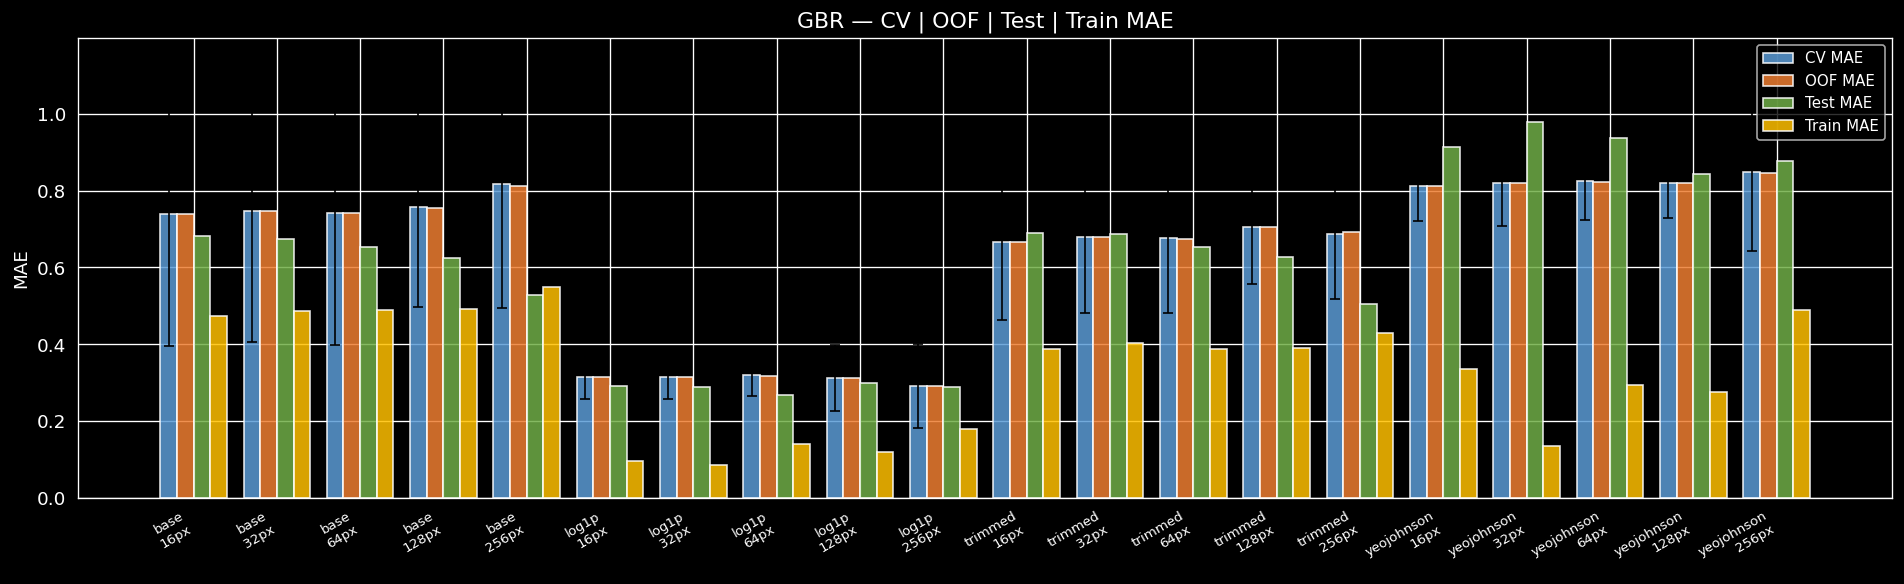

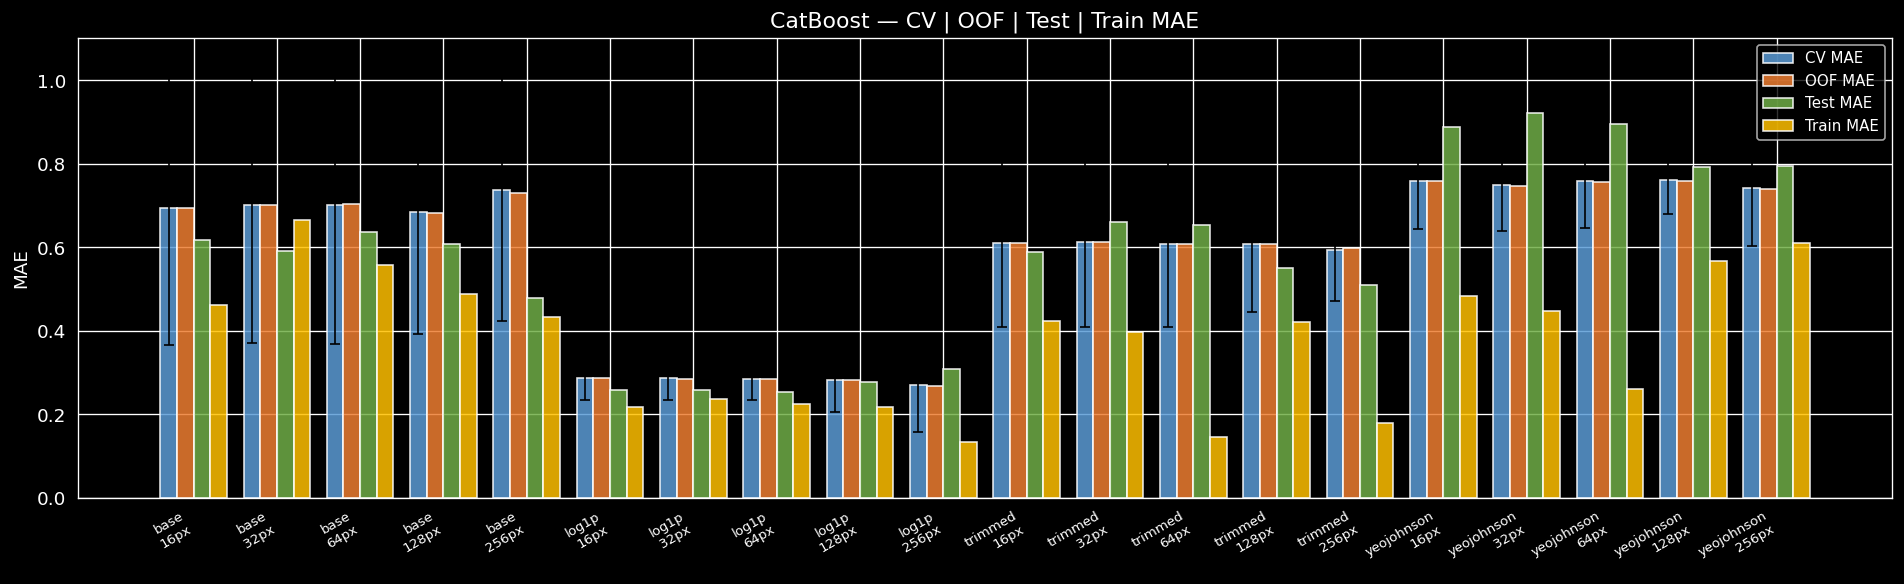

In [22]:
for mtype in model_order:
    sub = metrics_df[metrics_df['model'] == mtype].copy()
    sub['label'] = sub['dataset'] + '\n' + sub['patch_px'].astype(str) + 'px'
    sub = sub.sort_values(['dataset', 'patch_px'])

    x = np.arange(len(sub))
    w = 0.20

    fig, ax = plt.subplots(figsize=(max(10, len(sub)*0.8), 5))
    ax.bar(x - 1.5*w, sub['cv_mae'],    width=w, label='CV MAE',    color='#5B9BD5', alpha=0.85)
    ax.bar(x - 0.5*w, sub['oof_mae'],   width=w, label='OOF MAE',   color='#ED7D31', alpha=0.85)
    ax.bar(x + 0.5*w, sub['test_mae'],  width=w, label='Test MAE',  color='#70AD47', alpha=0.85)
    ax.bar(x + 1.5*w, sub['train_mae'], width=w, label='Train MAE', color='#FFC000', alpha=0.85)
    ax.errorbar(x - 1.5*w, sub['cv_mae'], yerr=sub['cv_mae_std'],
                fmt='none', color='black', capsize=3, lw=1)

    ax.set_xticks(x)
    ax.set_xticklabels(sub['label'], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('MAE')
    ax.set_title(f'{mtype} — CV | OOF | Test | Train MAE')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(RES_DIR / f'overfitting_{mtype}.png', bbox_inches='tight')
    plt.show()

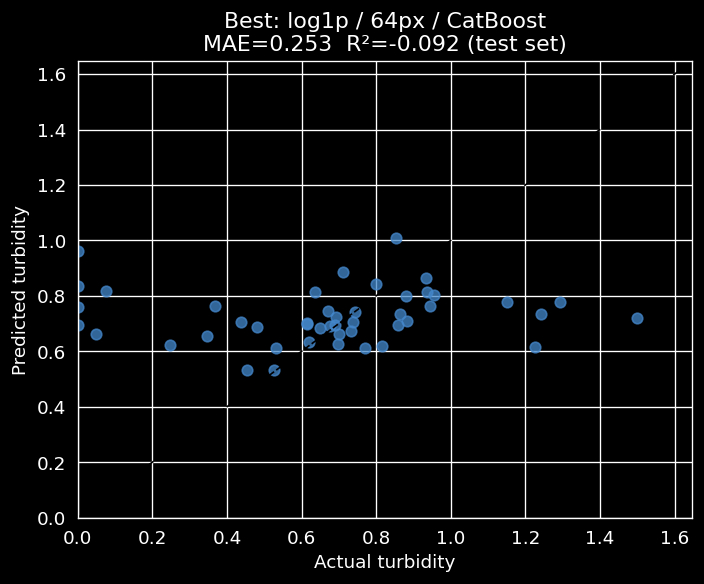

In [23]:
best_info = json.load(open(RES_DIR / 'best_model_info.json'))

mask = ((test_df['dataset']  == best_info['best_dataset']) &
        (test_df['patch_px'] == best_info['best_patch_px']) &
        (test_df['model']    == best_info['best_model']))
sub_test = test_df[mask]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sub_test['turbidity'], sub_test['pred'], alpha=0.75, s=40, color='#4488cc')
lim = [min(sub_test['turbidity'].min(), sub_test['pred'].min()) * 0.9,
       max(sub_test['turbidity'].max(), sub_test['pred'].max()) * 1.1]
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual turbidity')
ax.set_ylabel('Predicted turbidity')
ax.set_title(f'Best: {best_info["best_dataset"]} / {best_info["best_patch_px"]}px / '
             f'{best_info["best_model"]}\n'
             f'MAE={best_info["test_mae"]:.3f}  R²={best_info["test_r2"]:.3f} (test set)')
plt.tight_layout()
plt.savefig(RES_DIR / 'best_model_scatter.png', bbox_inches='tight')
plt.show()

## 9. Best configuration per dataset

In [24]:
best_per_ds = (
    metrics_df.sort_values('test_mae')
    .groupby('dataset', sort=False)
    .first()
    [['patch_px', 'model', 'train_mae', 'oof_mae', 'cv_mae', 'test_mae', 'test_r2', 'n_iters']]
    .rename(columns={
        'patch_px': 'best_patch', 'model': 'best_model',
        'train_mae': 'Train MAE', 'oof_mae': 'OOF MAE',
        'cv_mae': 'CV MAE', 'test_mae': 'Test MAE', 'test_r2': 'Test R²',
    })
)

print('Best combination per dataset (by test MAE):')
display(best_per_ds)

print(f'\nGlobal best: {best_info["best_dataset"]} / {best_info["best_patch_px"]}px / '
      f'{best_info["best_model"]}  →  Test MAE={best_info["test_mae"]:.4f}')

Best combination per dataset (by test MAE):


,best_patch,best_model,Train MAE,OOF MAE,CV MAE,Test MAE,Test R²,n_iters
dataset,,,,,,,,
log1p,64,CatBoost,0.2234,0.2834,0.2841,0.2532,-0.0916,30
base,256,CatBoost,0.4336,0.7298,0.7358,0.4789,0.1499,11
trimmed,256,GBR,0.4296,0.6920,0.6875,0.5050,0.0470,801
yeojohnson,128,CatBoost,0.5658,0.7586,0.7601,0.7920,-0.0986,18



Global best: log1p / 64px / CatBoost  →  Test MAE=0.2532
